In [181]:
import sys

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import os
import pandas as pd
import numpy as np
import scipy.fft as sf
import scipy.signal as sp
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile


from get_data.wav.get_data_from_rhumrum import get_rhumrum_data
from real_data_analysis.rhumrum.ambient_noise.segmentation_nmf import apply_nmf_v2

# Test de deux méthodes d'estimation du bruit ambiant 

**Objectif** : l'objectif est de comparer deux méthodes d'estimation de la DSP du bruit $S_{vv}(f)$. 

**Cas d'étude** : on étudie 24 H de données du réseau RHUM RUM, la journée étudiée est la journée du 2013-05-31 correspondant au cas d'étude de Jean Lecoulant dans l'article NMF.
 
**Paramètres globaux** :
- Taille des fenêtres $\approx$ 5 minutes 

## Méthode 1 : estimation du minimum

On fait, au choix, l'une des deux hypothèses suivantes : 
- La trajectoire du navire engendre un décalage Doppler significatif et les raies dans le signal sont progressivement shiftées. 
- La période d'étude est telle qu'il existe des portions de signal dans lesquelles le signal de navire est absent (ou dominé par le bruit ambiant)

$\hat{S}_{vv}(f) = \min_{t\in [0, t_{max}]} {\hat{S}_{xx}(f)}$


## Méthode 2 : segmentation du signal 

On fait l'hypothèse qu'il existe des portions du signal dans lesquelles le signal de navire est largement dominé par le bruit ambiant. 
On utilise une méthode de détection des signaux de navires pour segmenter le signal et extraire les portions ne contenant pas de bruit de navire. En l'occurrence on se propose ici d'utiliser une méthode de séparation de source par NMF : 

Jean Lecoulant, Abdel-Ouahab Boudraa, Samuel Pinson; Non-negative matrix factorization based single-channel source-separation of passive underwater acoustic signals in deep sea. JASA Express Lett. 1 February 2025; 5 (2): 026004. https://doi.org/10.1121/10.0035936



## Chargement des données 

In [182]:
station_id = "RR48"
date = "2013-05-31T00:00:00"
duration_h = 24
duration_sec = duration_h * 60 * 60
root_wav = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\rhumrum\ambient_noise\wav"
channels = ["BDH"]
if not os.path.exists(root_wav):
    os.makedirs(root_wav)

In [183]:
# # To run only once

# get_rhumrum_data(
#     station_id,
#     date,
#     duration_sec,
#     fmin=8.0,
#     fmax=46.0,
#     filter_type="bandpass",
#     filter_corners=2,
#     channels=channels,
#     save=True,
#     root_wav=root_wav,
#     plot=False,
# )

In [184]:
ref_dB = 20 * np.log10(1e6)  # Reference 1 uPa

In [185]:
# Load data (once previous cell run successfully)
# Build filename
fmt = "%Y-%m-%d_%H-%M-%S"
date_start = pd.to_datetime(date).strftime(fmt)
date_end = (
    pd.to_datetime(date) + pd.Timedelta(seconds=duration_sec)
).strftime(fmt)
fname = f"signal_{channels[0]}_{station_id}_{date_start}_{date_end}.wav" 
fpath = os.path.join(root_wav, fname)
fs, wav_data = wavfile.read(
    fpath
    )


# Derive stft
# nperseg = 5 * 60 * fs
nperseg = 2**10
noverlap = int(nperseg * 0.5)
ff, tt, stft = sp.stft(
    wav_data,
    fs=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap,
)
stft[stft==0] = 1e-50

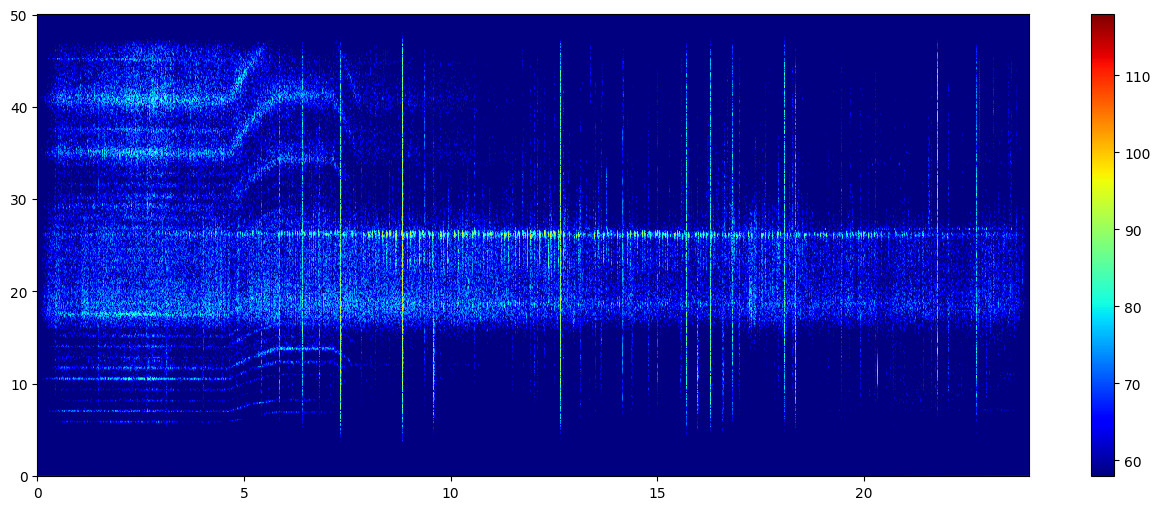

In [186]:
# Plot spectrogram
dyn = 60
vmax = np.max(20 * np.log10(abs(stft))) + ref_dB
vmin = vmax - dyn

tt_hour = tt / 3600
plt.figure(figsize=(16, 6))
plt.pcolormesh(
    tt_hour,
    ff,
    20 * np.log10(np.abs(stft)) + ref_dB,
    # shading="gouraud",
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
plt.colorbar()
plt.show()

## Méthode 1

### Step 0 : calcul stft avec fenêtre de 5 min
Il s'agit de la taille des fenêtres considérée par Samuel 

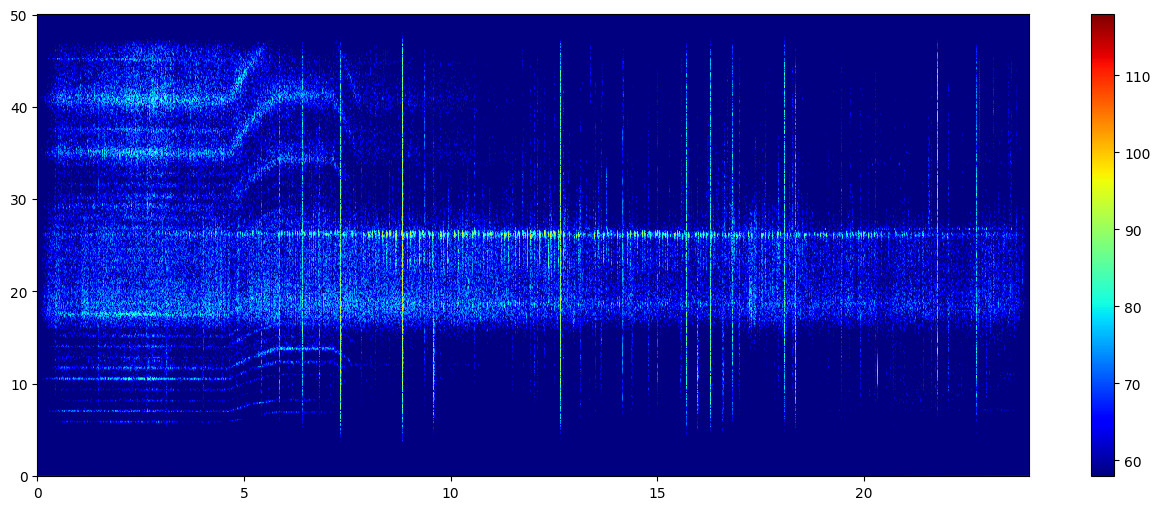

In [187]:
# Derive stft

# With long windows 
# nperseg_long = 5 * 60 * fs
# nperseg = 2**10
# noverlap_long = int(nperseg_long * 0.5)
# ff_long_win, tt_longwin, stft_longwin = sp.stft(
#     wav_data, fs=fs, window="hann", nperseg=nperseg_long, noverlap=noverlap_long
# )
# stft_longwin[stft_longwin == 0] = 1e-50

# With short windows 
stft_longwin = stft.copy()
tt_longwin = tt.copy()
ff_long_win = ff.copy()

# Plot spectrogram
dyn = 60
vmax_long = np.max(20 * np.log10(abs(stft_longwin))) + ref_dB
vmin_long = vmax_long - dyn

tt_hour_longwin = tt_longwin / 3600
plt.figure(figsize=(16, 6))
plt.pcolormesh(
    tt_hour_longwin,
    ff_long_win,
    20 * np.log10(np.abs(stft_longwin)) + ref_dB,
    # shading="gouraud",
    cmap="jet",
    vmin=vmin_long,
    vmax=vmax_long,
)
plt.colorbar()
plt.show()

### Step 3 : calcul de la DSP et du minimum 

In [188]:
s_xx = 2 * np.mean(np.abs(stft_longwin) ** 2, axis=1)
# window = np.hanning(nperseg-noverlap)
# c_amp = np.abs(np.sum(window))
f_xx, s_xx_welch = sp.welch(wav_data, fs=fs, nperseg=nperseg, noverlap=noverlap, scaling="spectrum")

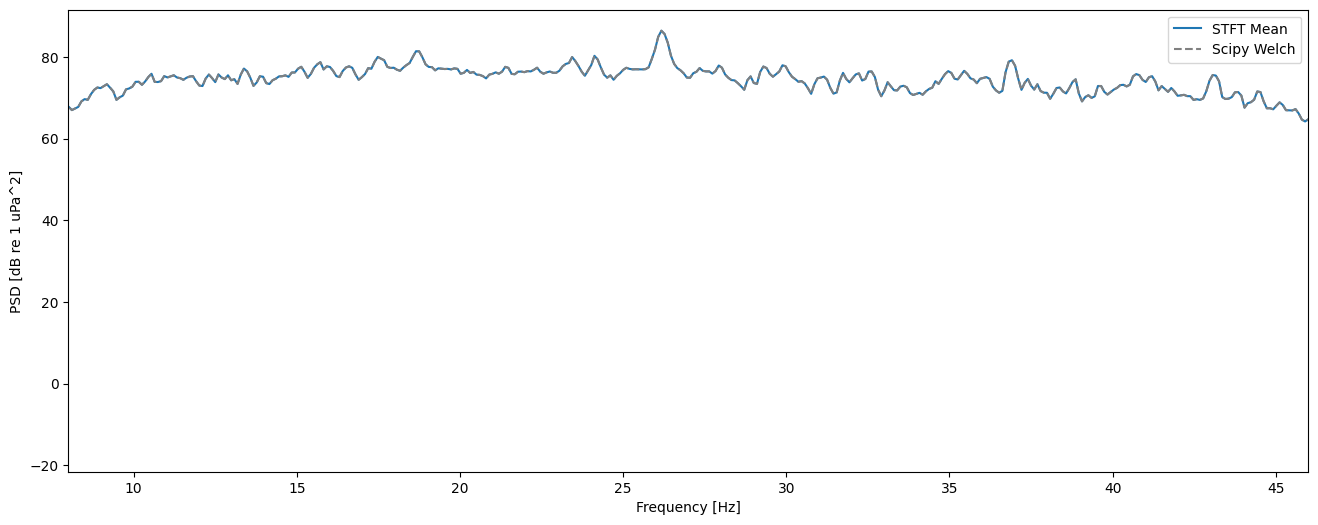

In [189]:
# Plot PSD 
plt.figure(figsize=(16, 6))
plt.plot(ff_long_win, 10 * np.log10(s_xx) + ref_dB, label="STFT Mean")
plt.plot(f_xx, 10 * np.log10(s_xx_welch) + ref_dB, "--", color="gray", label="Scipy Welch")
# plt.xscale("log")
plt.xlim([8, 46])
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB re 1 uPa^2]")
# plt.ylim([0, 75])
plt.legend()

Text(0.5, 1.0, 'Cropped Spectrogram')

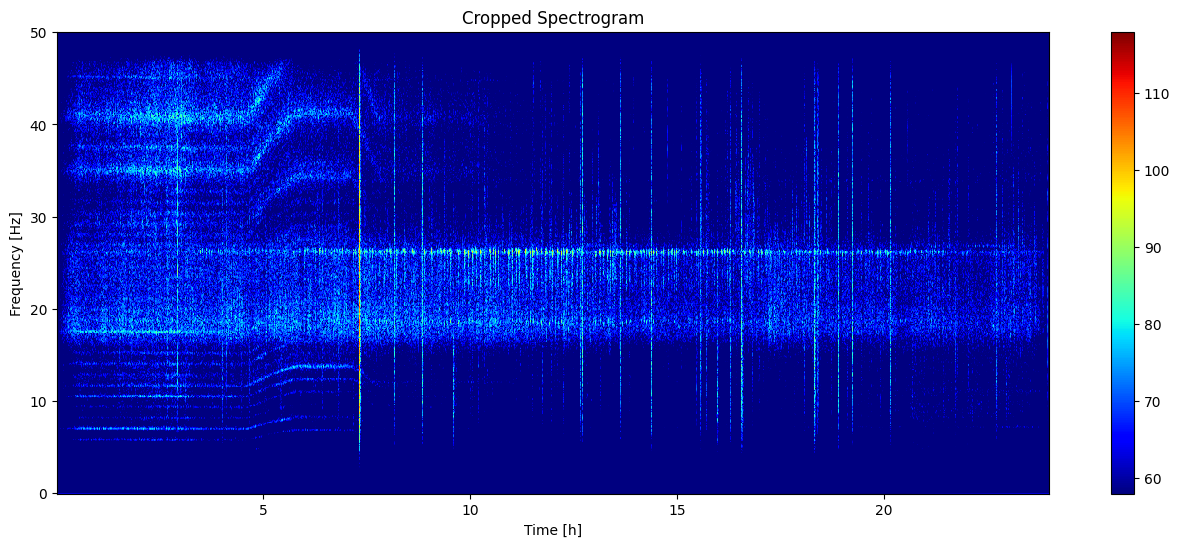

In [190]:
# Crop along time axis to avoid boundary effects (zeros at the beginning and end due to windowing)
n_win_cropp = 5
stft_longwin_cropped = stft_longwin[:, n_win_cropp:-n_win_cropp]
tt_longwin_cropped = tt_longwin[n_win_cropp:-n_win_cropp]

# Plot cropped spectrogram
plt.figure(figsize=(16, 6))
plt.pcolormesh(
    tt_longwin_cropped / 3600,
    ff_long_win,
    20 * np.log10(np.abs(stft_longwin_cropped)) + ref_dB,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
plt.colorbar()
plt.xlabel("Time [h]")
plt.ylabel("Frequency [Hz]")
plt.title("Cropped Spectrogram")

(-30.0, 50.0)

<Figure size 640x480 with 0 Axes>

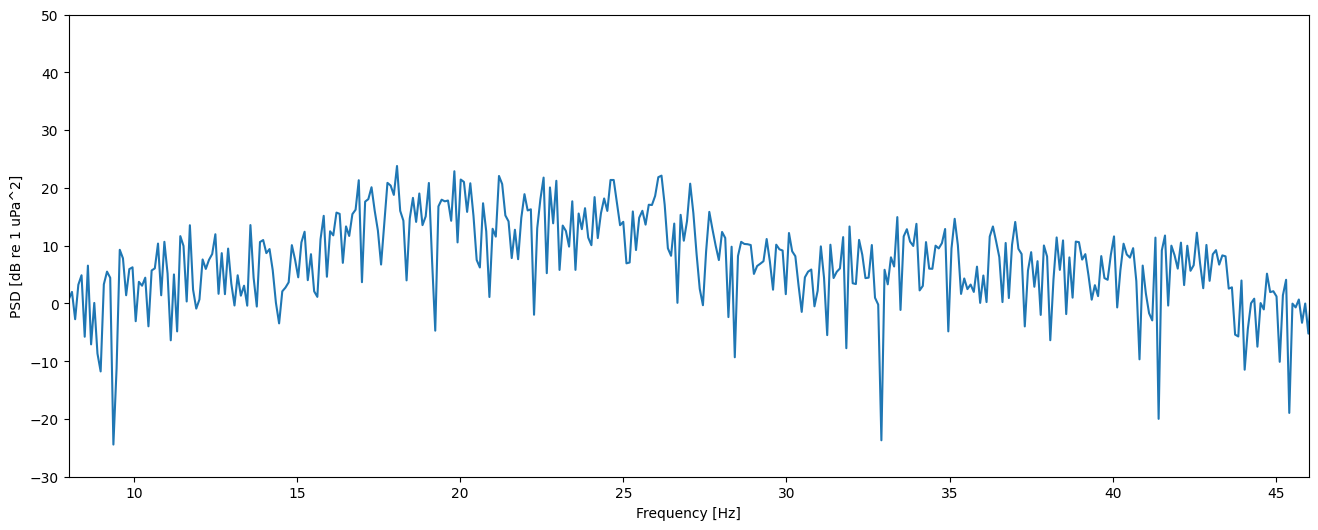

In [191]:
# Compute PSD of each snapshot
s_xx_win = np.abs(stft_longwin_cropped)**2  

window = np.hanning(nperseg - noverlap)
c_den = np.sqrt(np.sum(np.abs(window) ** 2))
# Normalize the manual PSD
s_xx_min = 4 * 1 / fs * 1 / (c_den**2) * s_xx_win

# Take the minimum over the time axis for each frequency bins
s_xx_min = np.min(s_xx_win, axis=1)

# Plot
plt.figure()

# Plot PSD
plt.figure(figsize=(16, 6))
plt.plot(ff_long_win, 10 * np.log10(s_xx_min) + ref_dB)
# plt.plot(f_xx, 10 * np.log10(s_xx_welch) + ref_dB, "--", color="gray")
# plt.xscale("log")
plt.xlim([8, 46])
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB re 1 uPa^2]")
plt.ylim([-30, 50])

## 

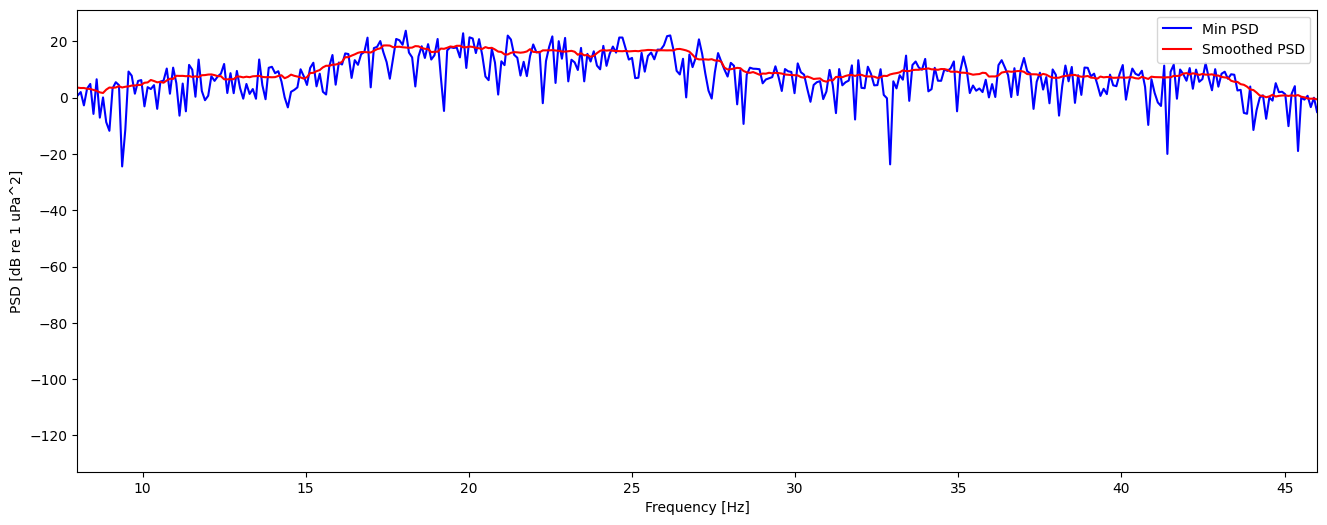

In [192]:
# Apply rolling average to smooth the PSD
window_size = 15  # Number of frequency bins to average over
s_xx_min_smooth = pd.Series(s_xx_min).rolling(window=window_size, center=True).mean().to_numpy()
# Plot smoothed PSD
plt.figure(figsize=(16, 6))
plt.xlim([8, 46])
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB re 1 uPa^2]")
plt.plot(ff_long_win, 10 * np.log10(s_xx_min) + ref_dB, label="Min PSD", color='blue')
plt.plot(ff_long_win, 10 * np.log10(s_xx_min_smooth) + ref_dB, label="Smoothed PSD", color='red')
plt.legend()

## Méthode 2

In [193]:
nperseg = 2**10
noverlap = int(nperseg * 0.5)
ff, tt, stft = sp.stft(
    wav_data,
    fs=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap,
)
stft[stft == 0] = 1e-50

### Step 1 : segmentation avec NMF

In [194]:
# Apply nmf
target_window_duration_s = 30 * 60 # 30 minutes 
n_stftwin_nmf = int(target_window_duration_s * fs / (nperseg-noverlap))
spZ, spT, spN = apply_nmf_v2(
    t_stft=tt, f_stft=ff, x_stft=stft, n_stftwin_nmf=n_stftwin_nmf, n_nmf_comp=50
)

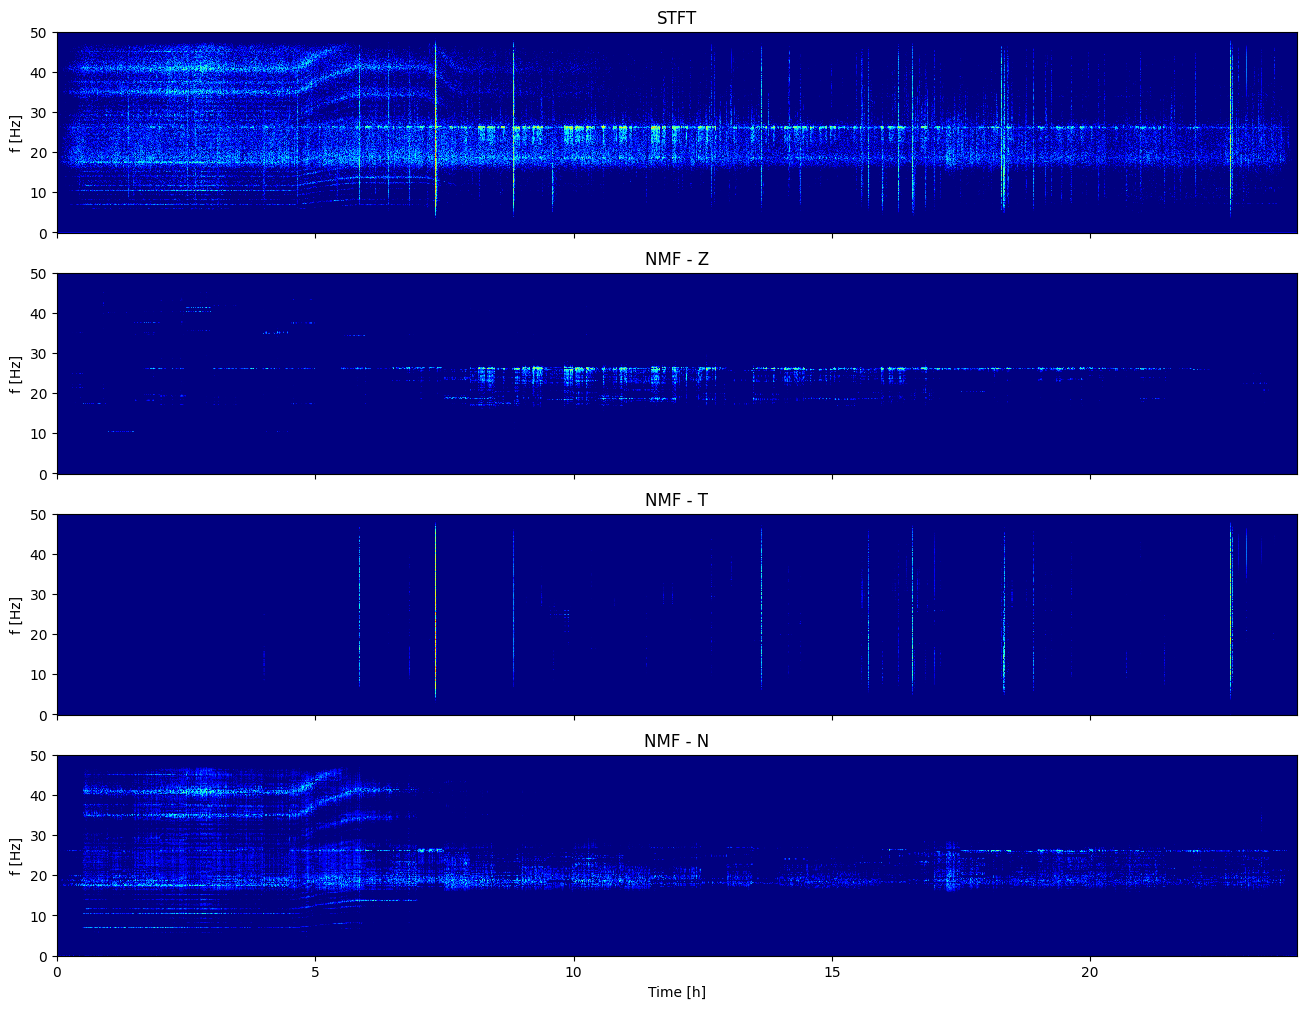

In [195]:
# Plot nmf spectrogram
stft[np.abs(stft) == 0] = 1e-50

fig, axs = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
mats = [stft, spZ, spT, spN]
titles = [
    "STFT",
    "NMF - Z",
    "NMF - T",
    "NMF - N",
]
for i_ax, ax_i in enumerate(axs):
    ax_i.pcolormesh(
        tt_hour,
        ff,
        20 * np.log10(np.abs(mats[i_ax])) + ref_dB,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    ax_i.set_ylabel("f [Hz]")
    ax_i.set_title(titles[i_ax])

axs[-1].set_xlabel("Time [h]")

plt.show()

## Step 2 : détection de navire 
La détection de navire est simplement basée sur le calcul de l'énergie du spectrogramme de la composante navire (séparé par NMF)

In [196]:
e_ship = np.sum(np.abs(spN)*2, axis=0)
e_ship = e_ship / np.max(e_ship)


(-30.0, 0.0)

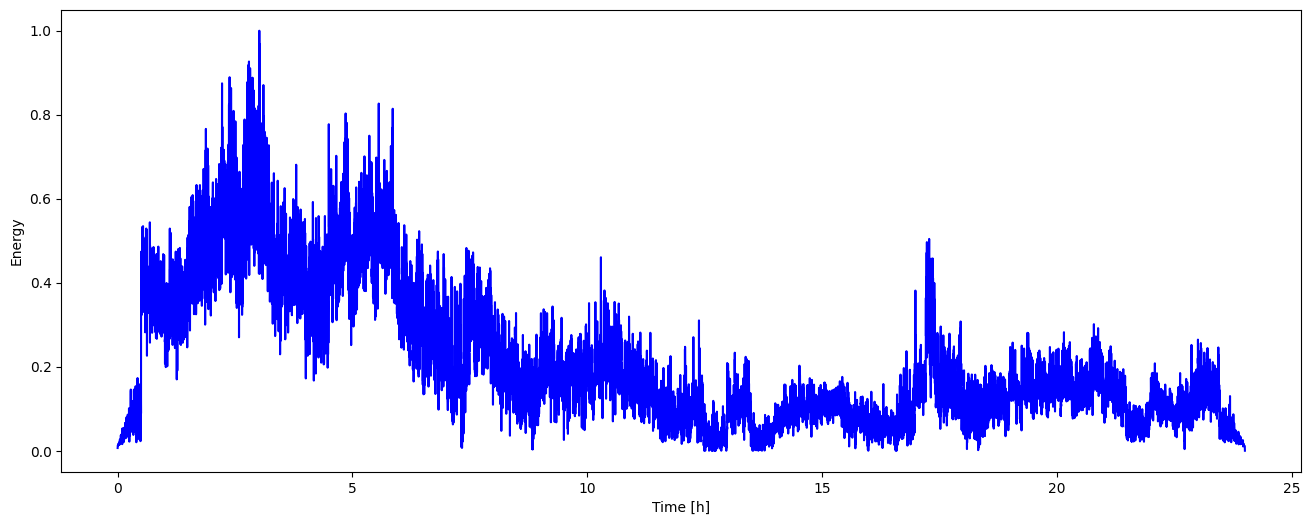

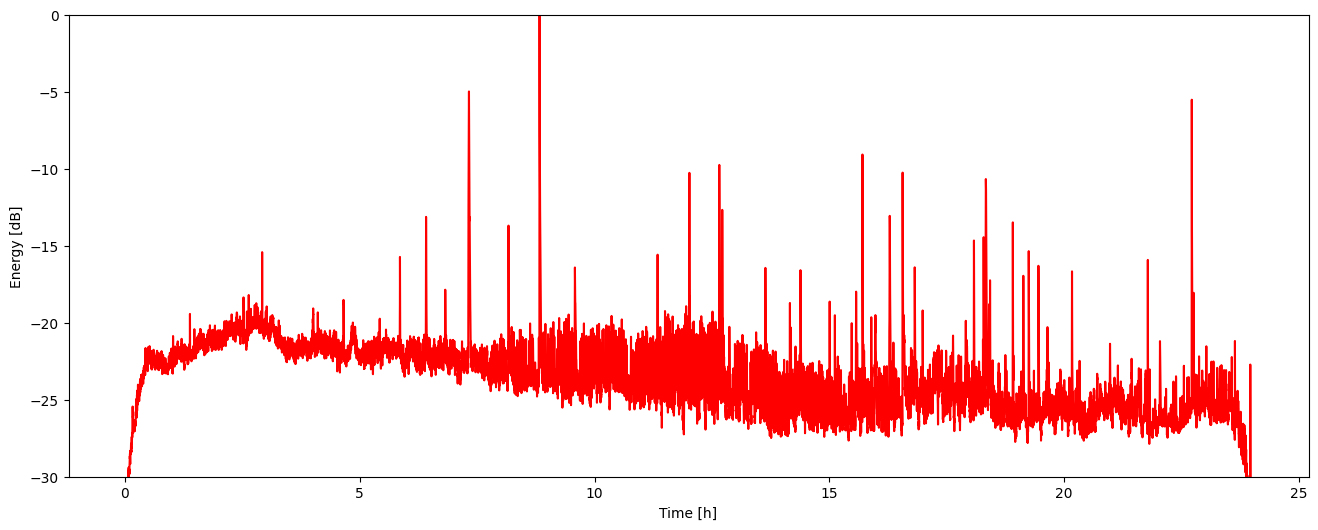

In [197]:
# Plot energy of ship
plt.figure(figsize=(16, 6))
plt.plot(tt_hour, e_ship, label="Ship energy", color='blue')
plt.xlabel("Time [h]")
plt.ylabel("Energy")

# Add total energy for comparison
total_energy = np.sum(np.abs(stft)*2, axis=0)
total_energy = total_energy / np.max(total_energy)
plt.figure(figsize=(16, 6))
plt.plot(tt_hour, 10*np.log10(total_energy), label="Total energy", color='red')
plt.xlabel("Time [h]")
plt.ylabel("Energy [dB]")
plt.ylim([-30, 0])
# plt.legend()

In [198]:
# Remove Z-call band for clarity
f_unit_A = 26.2
f_unit_C = 18.7
f_offset = 0.2
ff_mask = (ff >= f_unit_A + f_offset) | (ff <= f_unit_C - f_offset)

e_ship_nozcall = np.sum(np.abs(spN[ff_mask, :]) * 2, axis=0)

Text(0.5, 1.0, 'Energy of ship without Z-call band')

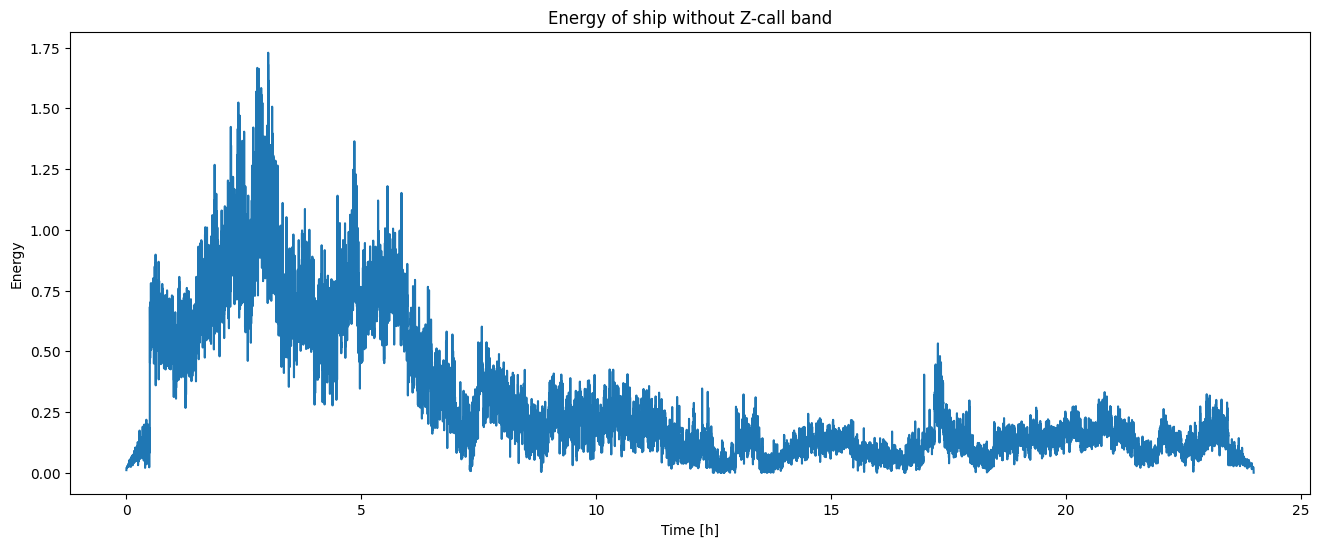

In [199]:
# Plot energy of ship without Z-call band
plt.figure(figsize=(16, 6))
plt.plot(tt_hour, e_ship_nozcall)
plt.xlabel("Time [h]")
plt.ylabel("Energy")
plt.title("Energy of ship without Z-call band")

In [200]:
# Apply rolling average to smooth the energy
window_duration = 60 * 60  # 5 minutes
window_size = int(window_duration * fs / (nperseg - noverlap))
e_ship_nozcall_smooth = pd.Series(e_ship_nozcall).rolling(window=window_size, min_periods=1).mean().values
# Normalize
e_ship_nozcall_smooth = e_ship_nozcall_smooth / np.max(e_ship_nozcall_smooth)

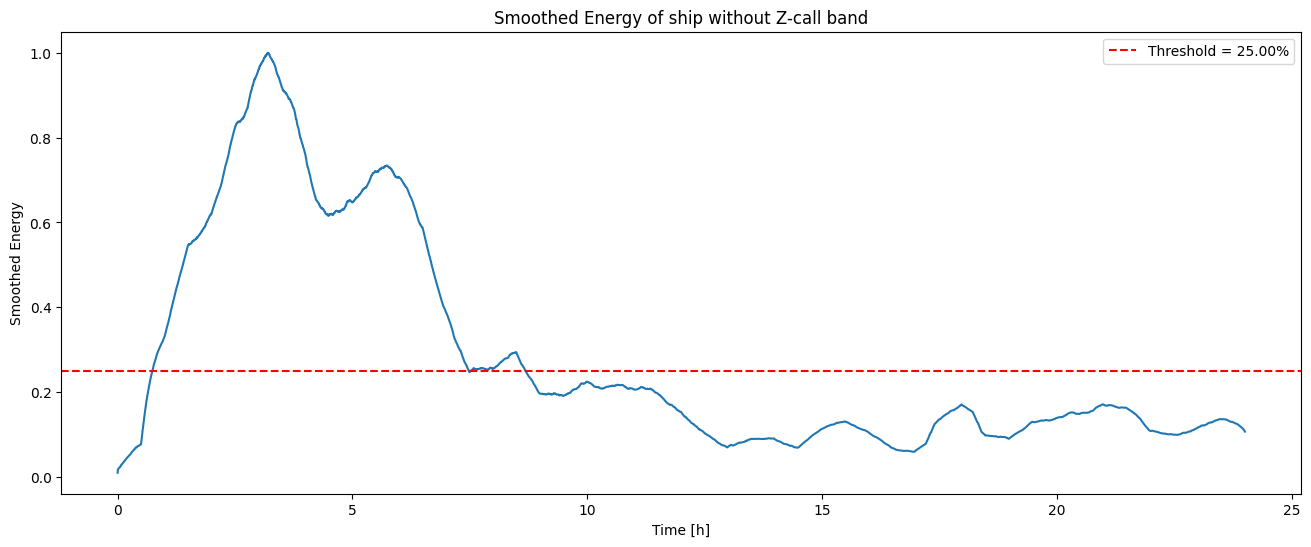

In [201]:
# Plot smoothed energy of ship without Z-call band
plt.figure(figsize=(16, 6))
plt.plot(tt_hour, e_ship_nozcall_smooth)
plt.xlabel("Time [h]")
plt.ylabel("Smoothed Energy")
plt.title("Smoothed Energy of ship without Z-call band")

# Add threshold
threshold = 0.25
# threshold = np.quantile(e_ship_nozcall_smooth, q=0.5) 
plt.axhline(
    threshold, color="red", linestyle="--", label=f"Threshold = {threshold*100:.2f}%"
)
plt.legend()


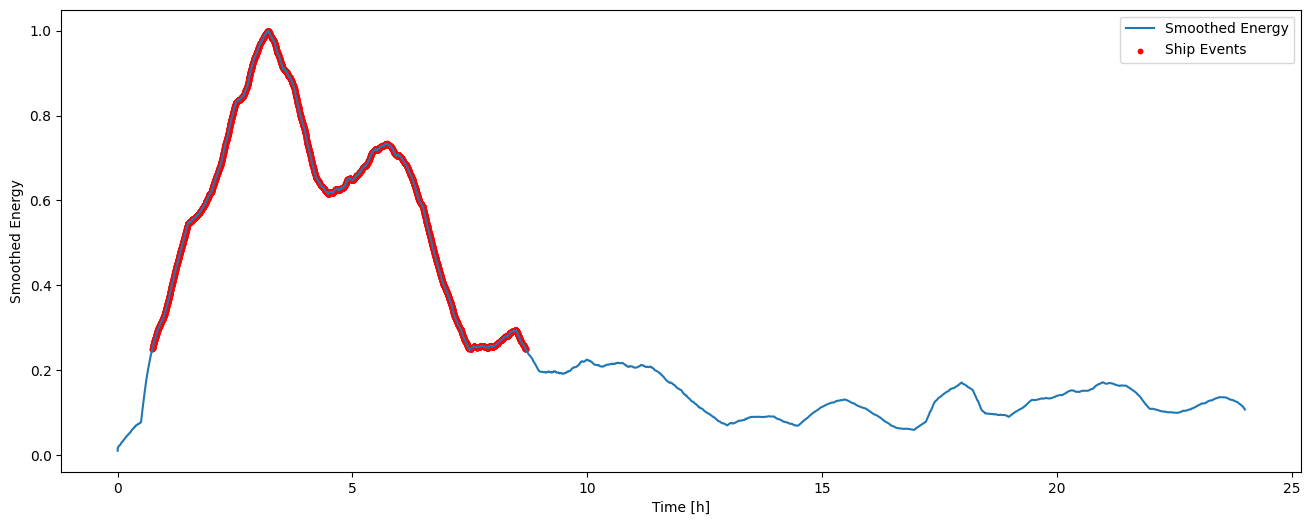

In [202]:
# Extract ship events
ship_events = np.where(e_ship_nozcall_smooth >= threshold)[0]
# Convert indices to time
ship_event_times = tt_hour[ship_events]
# Plot smoothed energy with ship events highlighted
plt.figure(figsize=(16, 6))
plt.plot(tt_hour, e_ship_nozcall_smooth, label="Smoothed Energy")
plt.scatter(ship_event_times, e_ship_nozcall_smooth[ship_events], color='red', label='Ship Events', s=10)
plt.xlabel("Time [h]")
plt.ylabel("Smoothed Energy")
# plt.xlim([5, 10])
plt.legend()

Text(0.5, 0, 'Time [h]')

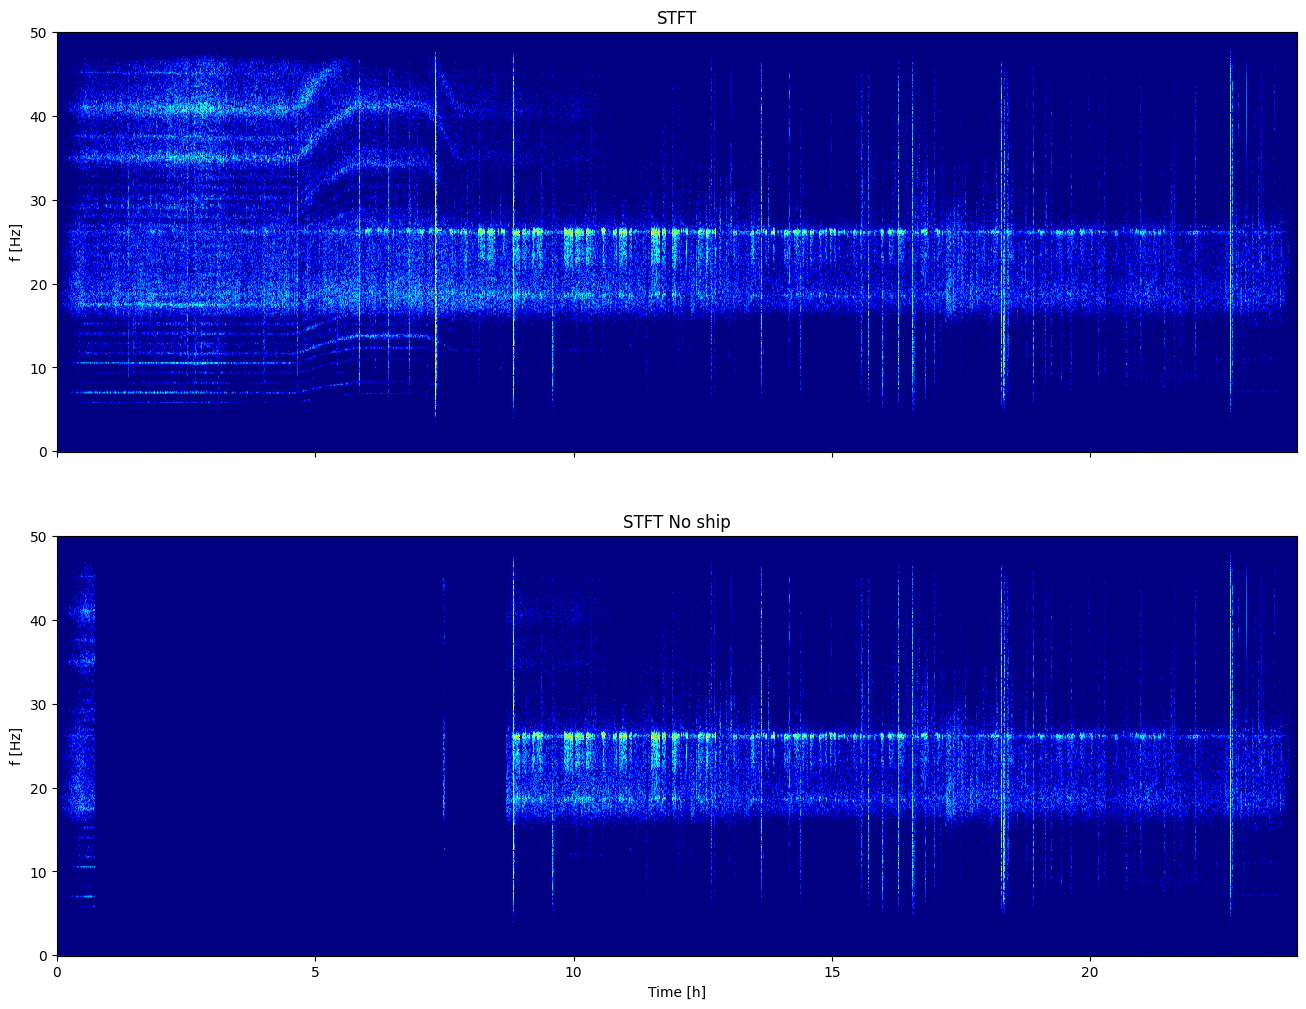

In [203]:
# Plot original spectrogram without the ship events
stft_noship = stft.copy()
stft_noship[:, ship_events] = 1e-50 


fig, axs = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
mats = [stft, stft_noship]
titles = [
    "STFT",
    "STFT No ship",
]
for i_ax, ax_i in enumerate(axs):
    ax_i.pcolormesh(
        tt_hour,
        ff,
        20 * np.log10(np.abs(mats[i_ax])) + ref_dB,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    ax_i.set_ylabel("f [Hz]")
    ax_i.set_title(titles[i_ax])

axs[-1].set_xlabel("Time [h]")

### Step 3 : calcul de la DSP sur le spectrogramme sans bateau 

In [204]:
stft_noship = stft[:, ~ship_events]

# Apply welch

window = np.hanning(nperseg - noverlap)
c_den = np.sqrt(np.sum(np.abs(window) ** 2))
p_xx_manual_spectrum = np.mean(np.abs(stft_noship) ** 2, axis=1)        # Pa**2 / Hz**2
# Normalize the manual PSD
p_xx_density = (
    4 * p_xx_manual_spectrum * np.abs(np.sum(window)) ** 2 / (fs * c_den**2)
)

# s_xx = p_xx_density
s_xx  = p_xx_manual_spectrum


# s_xx = np.mean(np.abs(stft_noship) ** 2, axis=1)  # Welch

(8, 46)

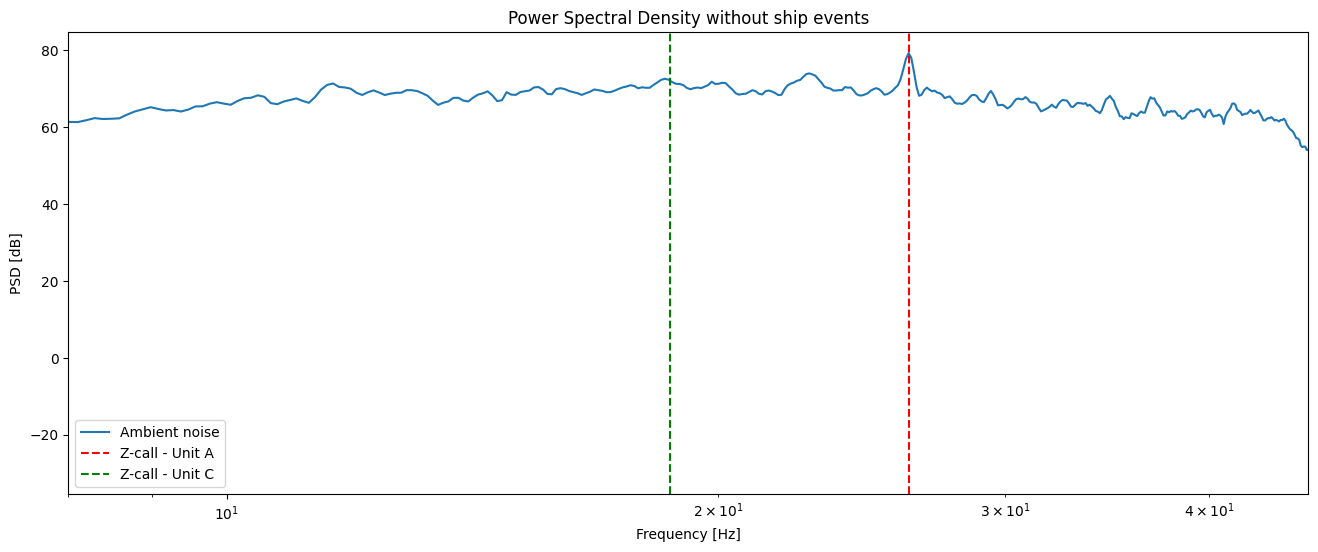

In [205]:
# Plot PSD
plt.figure(figsize=(16, 6))
plt.plot(ff, 10 * np.log10(s_xx) + ref_dB, label="Ambient noise")
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Power Spectral Density without ship events")

plt.axvline(f_unit_A, color='red', linestyle='--', label='Z-call - Unit A')
plt.axvline(f_unit_C, color='green', linestyle='--', label='Z-call - Unit C')
plt.legend()

# Restrict to not filtered band
plt.xlim([8, 46])       # Butterrworth bandpass filter range

Remarque sur le bruit ambiant : le bruit ambiant est généralement considéré comme un bruit rose (pente de -1 dans le diagramme log/log), ici le bruit est plutôt blanc. 

## Comparaison 

Text(0, 0.5, 'PSD [dB]')

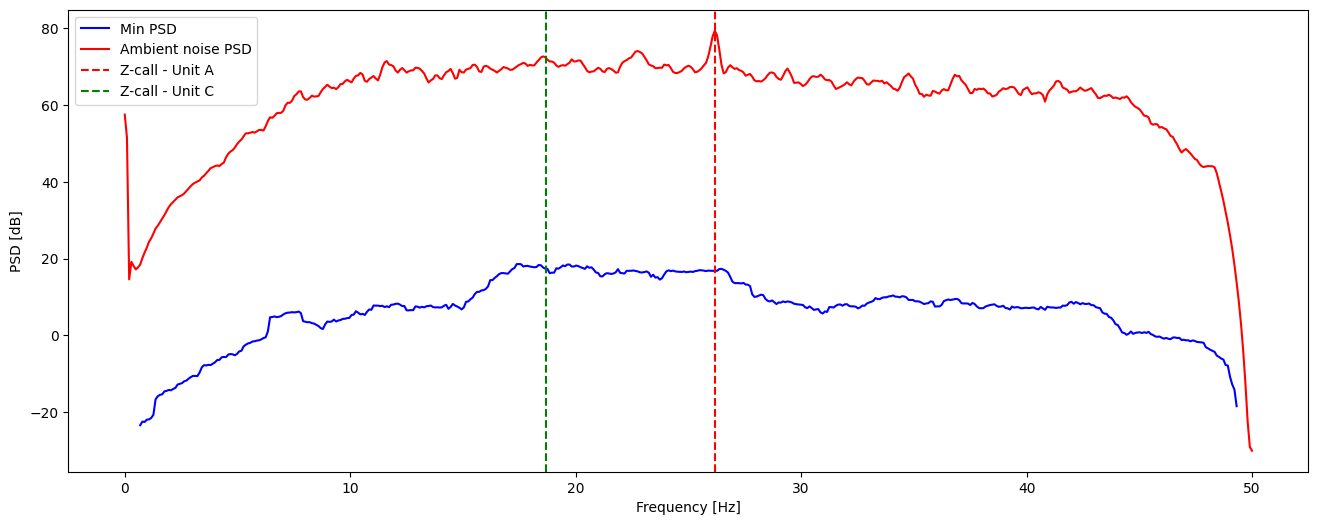

In [206]:
# Compare both estimates
plt.figure(figsize=(16, 6))
plt.plot(ff_long_win, 10 * np.log10(s_xx_min_smooth) + ref_dB, label="Min PSD", color='blue')
plt.plot(ff, 10 * np.log10(s_xx) + ref_dB, label="Ambient noise PSD", color="red")

plt.axvline(f_unit_A, color="red", linestyle="--", label="Z-call - Unit A")
plt.axvline(f_unit_C, color="green", linestyle="--", label="Z-call - Unit C")
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB]")

In [207]:
# nperseg = 2**10
# noverlap = int(nperseg * 0.5)
# ff, tt, stft = sp.stft(
#     wav_data,
#     fs=fs,
#     window="hann",
#     nperseg=nperseg,
#     noverlap=noverlap,
# )
# # stft[stft == 0] = 1e-50

# window = np.hanning(nperseg - noverlap)
# # window = np.ones(nperseg - noverlap)  # Boxcar window
# c_den = np.sqrt(np.sum(np.abs(window) ** 2))
# p_xx_manual_spectrum = np.mean(np.abs(stft) ** 2, axis=1)  # Pa**2 / Hz**2
# # Normalize the manual PSD
# p_xx_manual_density = (
#     4 * p_xx_manual_spectrum * np.abs(np.sum(window)) ** 2 / (fs * c_den**2)
# )  # Pa**2 / Hz

# # Compute PSD using Welch method
# f_xx_sp, p_xx_sp_welch = sp.welch(
#     wav_data,
#     fs=fs,
#     nperseg=nperseg,
#     noverlap=noverlap,
#     scaling="density",
#     window="hann",   
# )
# delta = 10 * np.log10(p_xx_sp_welch) - 10 * np.log10(p_xx_manual_density)

# print(np.max(delta))

# # Plot comparison of manual PSD and Welch PSD
# plt.figure(figsize=(16, 6))
# plt.plot(
#     ff, 10 * np.log10(p_xx_manual_density) + ref_dB, label="Manual PSD", color="blue"
# )
# plt.plot(f_xx_sp, 10 * np.log10(p_xx_sp_welch) + ref_dB, label="Welch PSD", color='red')
# plt.xlabel("Frequency [Hz]")
# plt.ylabel("PSD [dB]")
# # plt.ylim([0, 100])
# plt.xlim([8, 46])
# plt.legend()

In [208]:
# plt.figure(figsize=(16, 6))
# plt.plot(
#     ff,
#     10 * np.log10(p_xx_sp_welch) - 10 * np.log10(p_xx_manual_density),
#     label="Min PSD",
#     color="blue",
# )
# plt.xlim([8, 46])
# plt.ylim([0, 10])